In [2]:
%reload_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader 
from sklearn.model_selection import train_test_split
from DataEncoder import encode_pad_event, encode_pad_sequence, scale_time_differences, scale_time_differences_fast_fixed, encode_label_event, node_time_list, length_stratified_split
from GATConvTimeDecay import prepare_data_core, prepare_data_y, CustomDataset, normalize_attention_minmax, min_max_normalize, normalize_edge_scores
from GATConvTimeDecay import EarlyStopping, train, evaluate, custom_collate_fn, TimeAwareGATConv, DualGATTimeAwareModel
from GATConvTimeDecay import vectorized_find_longest, get_samples_in_node_range
from GATConvTimeDecay import get_length_bins_from_attention, get_quantile_bins_from_attention, compute_importance_stats, plot_heatmap_from_stats, plot_rank_dominance, plot_importance_timeline, plot_critical_windows, generate_pairwise_ttest_table, get_top_significant_ranges, calculate_window_metrics, aggregate_metrics, plot_window_metrics
from GATConvTimeDecay import predict, top_k_accuracy, predict_per_sequence, average_bleu_score, compute_dls_and_exact_match, sequence_level_top_k_accuracy, analyze_sequence_errors, predict_per_sequence_with_probs, sequence_level_top_k_analysis, show_error_sequences
import os 
import shutil

In [3]:
#event = pd.read_csv("../output/BPI12.csv")
# event = pd.read_csv("../output/BPI12w.csv")
#event = pd.read_csv("../output/BPI13i.csv")
#event = pd.read_csv("../output/BPI13c.csv")
event = pd.read_csv("../output/helpdesk.csv")

In [4]:
# check the size of sequence
shortest_sequence = event.groupby('sequence').size().min()
longest_sequence = event.groupby('sequence').size().max()
print('shortest_sequence:', shortest_sequence)
print('longest_sequence:', longest_sequence)

shortest_sequence: 2
longest_sequence: 15


In [5]:
core_event = 'event'
#core_event = 'event_label'
case_index = 'sequence'
event = event[event.groupby(case_index)[case_index].transform('size') >= 2].reset_index(drop=True)

In [6]:
core_encode, y_encode, core_size, output_size, le_event = encode_label_event(event, core_event, case_index)

In [7]:
#event['ec1'] = event['ec1'].astype(str) 
# cat_col_event = ['ec1']
# num_col_event = []
#Bpi13
#cat_col_event = ['ec1', 'ec2', 'ec4', 'ec5']
#num_col_seq = []
#helpdesk
cat_col_event = ['ec1']
num_col_event = []
event_encode = encode_pad_event(event, cat_col_event, num_col_event, case_index, cat_mask = True, num_mask = True, eos = False)

In [8]:
# sequence = event[['sequence','sn1']].groupby('sequence').first()
#BPI13
#sequence = event[['sequence','sc3', 'sc1', 'sc2']].groupby('sequence').first()
sequence = event[['sequence','sc1']].groupby('sequence').first()
sequence = sequence.reset_index()

In [9]:
# cat_col_seq = []
# num_col_seq = ['sn1']
#BPI13
#cat_col_seq = ['sc1','sc2','sc3']
#num_col_seq = []
#helpdesk
cat_col_seq = ['sc1']
num_col_seq = []
sequence_encode = encode_pad_sequence(sequence, cat_col_seq, num_col_seq)

In [10]:
start_time_col = 'time'
scaled_time_diffs = scale_time_differences_fast_fixed(event, sequence, start_time_col, case_index)

In [11]:
max_num_events = event_encode.shape[1]
# Expand sequence features to match the shape of event features
sequence_features_expanded = np.expand_dims(sequence_encode, axis=1)
sequence_features_expanded = np.repeat(sequence_features_expanded, max_num_events, axis=1)

# Combine event and sequence features
combined_features = np.concatenate((event_encode, sequence_features_expanded), axis=2)

In [12]:
num_sequences = event_encode.shape[0]
num_event_features = combined_features.shape[2]
num_embedding_features = core_size

In [13]:
node_times = node_time_list(event, start_time_col, case_index)

In [14]:
event_feature_list = prepare_data_core(combined_features, core_encode, scaled_time_diffs, node_times)
y_list = prepare_data_y(combined_features, y_encode)

In [15]:
# Use stratified sampling over sequence length to preserve distributional characteristics
train_indices, test_indices = length_stratified_split(event_feature_list, test_size=0.2, n_bins=10)

# Split the data
train_event_features = [event_feature_list[i] for i in train_indices]
test_event_features = [event_feature_list[i] for i in test_indices]
train_y = [y_list[i] for i in train_indices]
test_y = [y_list[i] for i in test_indices]

# Print statistics
train_lengths = [event_feature_list[i].x.shape[0] for i in train_indices]
test_lengths = [event_feature_list[i].x.shape[0] for i in test_indices]

print(f"Train set: {len(train_indices)} samples")
print(f"Train length range: {min(train_lengths)} - {max(train_lengths)}")
print(f"Train length mean: {np.mean(train_lengths):.2f}")

print(f"\nTest set: {len(test_indices)} samples") 
print(f"Test length range: {min(test_lengths)} - {max(test_lengths)}")
print(f"Test length mean: {np.mean(test_lengths):.2f}")

Train set: 3666 samples
Train length range: 2 - 14
Train length mean: 4.57

Test set: 914 samples
Test length range: 3 - 15
Test length mean: 4.88


In [16]:
train_dataset = CustomDataset(train_event_features, train_y)
test_dataset = CustomDataset(test_event_features, test_y)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# parameters
embedding_dims = 64
gat_hidden_dim_event = 32
gat_hidden_dim_embed = 128
gat_hidden_dim_concat = 256
output_dim = output_size  # vocab size
num_heads = 4
lambda_decay = 0.01

model = DualGATTimeAwareModel(
    num_event_features=num_event_features,
    num_embedding_features=num_embedding_features,
    embedding_dims=embedding_dims,
    gat_hidden_dim_event=gat_hidden_dim_event,
    gat_hidden_dim_embed=gat_hidden_dim_embed,
    gat_hidden_dim_concat=gat_hidden_dim_concat,
    output_dim=output_dim,
    num_heads=num_heads,
    lambda_decay = lambda_decay
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
#criterion = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.1)  # ignore padding
criterion = nn.CrossEntropyLoss(ignore_index=-1) 

In [18]:
batch_size = 16  
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

In [19]:
num_epochs = 10

# Filepath to save model
model_path = "../output/models/1.pt"

config = {
    'model_type': 'DualGATTimeAwareModel',
    'num_event_features': num_event_features,
    'num_embedding_features': num_embedding_features,
    'embedding_dims': embedding_dims,
    'gat_hidden_dim_event': gat_hidden_dim_event,
    'gat_hidden_dim_embed': gat_hidden_dim_embed,
    'gat_hidden_dim_concat': gat_hidden_dim_concat,
    'output_dim': output_dim,
    'num_heads': num_heads,
    'lambda_decay': lambda_decay
}

early_stopping = EarlyStopping(patience=3, delta=0.0)

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, attention_data = evaluate(model, test_loader, criterion, device, return_attention=True)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

    if early_stopping(test_loss):
        print("Early stopping triggered.")
        break

    if early_stopping.best_loss_updated:
        print(f"New best model at epoch {epoch+1}, saving to {model_path}")
        best_model_saved = True
         # Save state dict and config
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config,
            'attention_data': attention_data
        }, model_path)
        
if not early_stopping.early_stop and not best_model_saved:
        print("Training completed without early stopping. Saving final model.")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config,
            'attention_data': attention_data
        }, model_path)


Epoch 1/10 | Train Loss: 1.3518 Acc: 0.6898 | Test Loss: 1.1960 Acc: 0.7145
New best model at epoch 1, saving to ../output/models/1.pt
Epoch 2/10 | Train Loss: 1.1206 Acc: 0.7277 | Test Loss: 1.0998 Acc: 0.7145
New best model at epoch 2, saving to ../output/models/1.pt
Epoch 3/10 | Train Loss: 1.0002 Acc: 0.7368 | Test Loss: 0.9654 Acc: 0.7367
New best model at epoch 3, saving to ../output/models/1.pt
Epoch 4/10 | Train Loss: 0.9028 Acc: 0.7429 | Test Loss: 0.8809 Acc: 0.7414
New best model at epoch 4, saving to ../output/models/1.pt
Epoch 5/10 | Train Loss: 0.8383 Acc: 0.7439 | Test Loss: 0.8228 Acc: 0.7405
New best model at epoch 5, saving to ../output/models/1.pt
Epoch 6/10 | Train Loss: 0.7892 Acc: 0.7459 | Test Loss: 0.8105 Acc: 0.7318
New best model at epoch 6, saving to ../output/models/1.pt
Epoch 7/10 | Train Loss: 0.7497 Acc: 0.7478 | Test Loss: 0.7866 Acc: 0.7360
New best model at epoch 7, saving to ../output/models/1.pt
Epoch 8/10 | Train Loss: 0.7209 Acc: 0.7473 | Test Loss

In [20]:
checkpoint = torch.load("../output/models/1.pt", map_location=device)
attention_data = checkpoint['attention_data']

In [22]:
import os
os.makedirs("../output/statis", exist_ok=True)
os.makedirs("../output/picts", exist_ok=True)

In [23]:
length_bins, bin_bf = get_length_bins_from_attention(attention_data, bin_size=5, max_len=None, 
                                                     save_path = "../output/statis/BPI12w_timedgedecay_bins.csv")
#length_bins = get_quantile_bins_from_attention(attention_data, num_bins=10)
range_stats, range_importances, topnode_df = compute_importance_stats(attention_data, length_bins, save_path = "../output/statis/BPI12w_timedgedecay_topnode.csv")

✅ Bin count saved to: ../output/statis/BPI12w_timedgedecay_bins.csv
📄 Saved importance summary to: ../output/statis/BPI12w_timedgedecay_topnode.csv


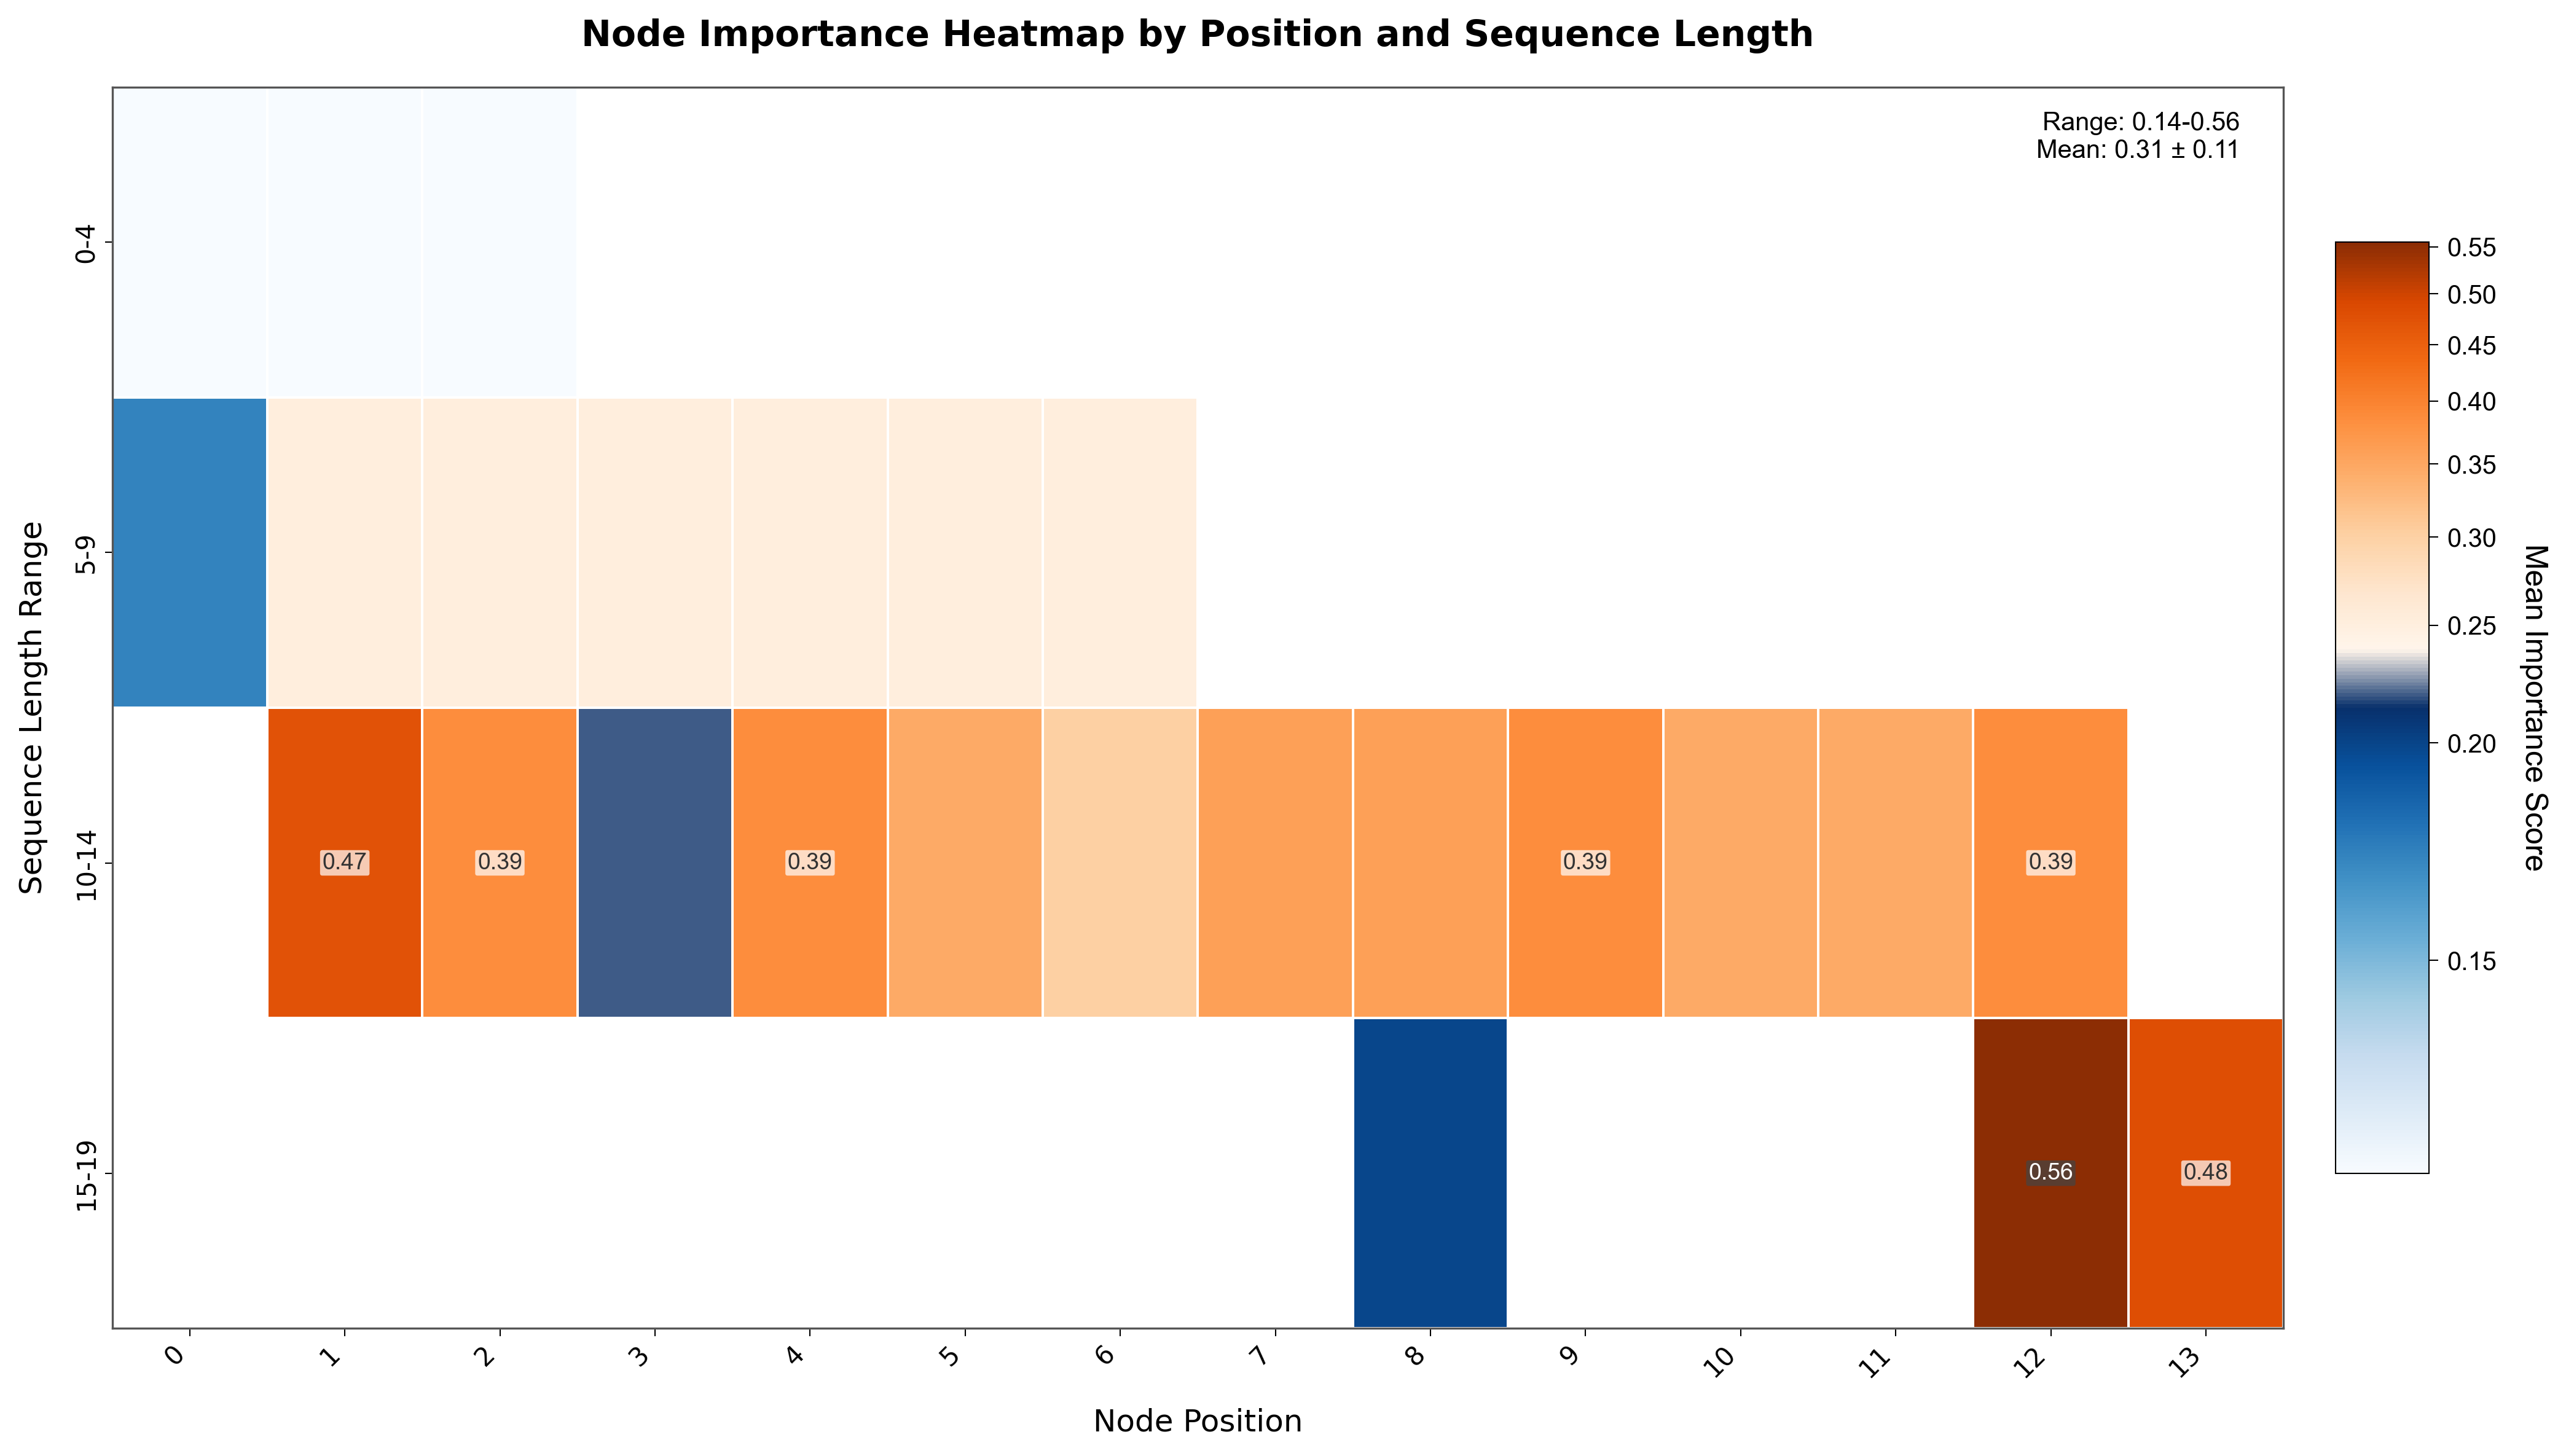

In [24]:
# Step 2: Generate heatmap from the same data
plot_heatmap_from_stats(range_stats, range_importances, "../output/picts/BPI12w_timedgedecay_heatmap")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


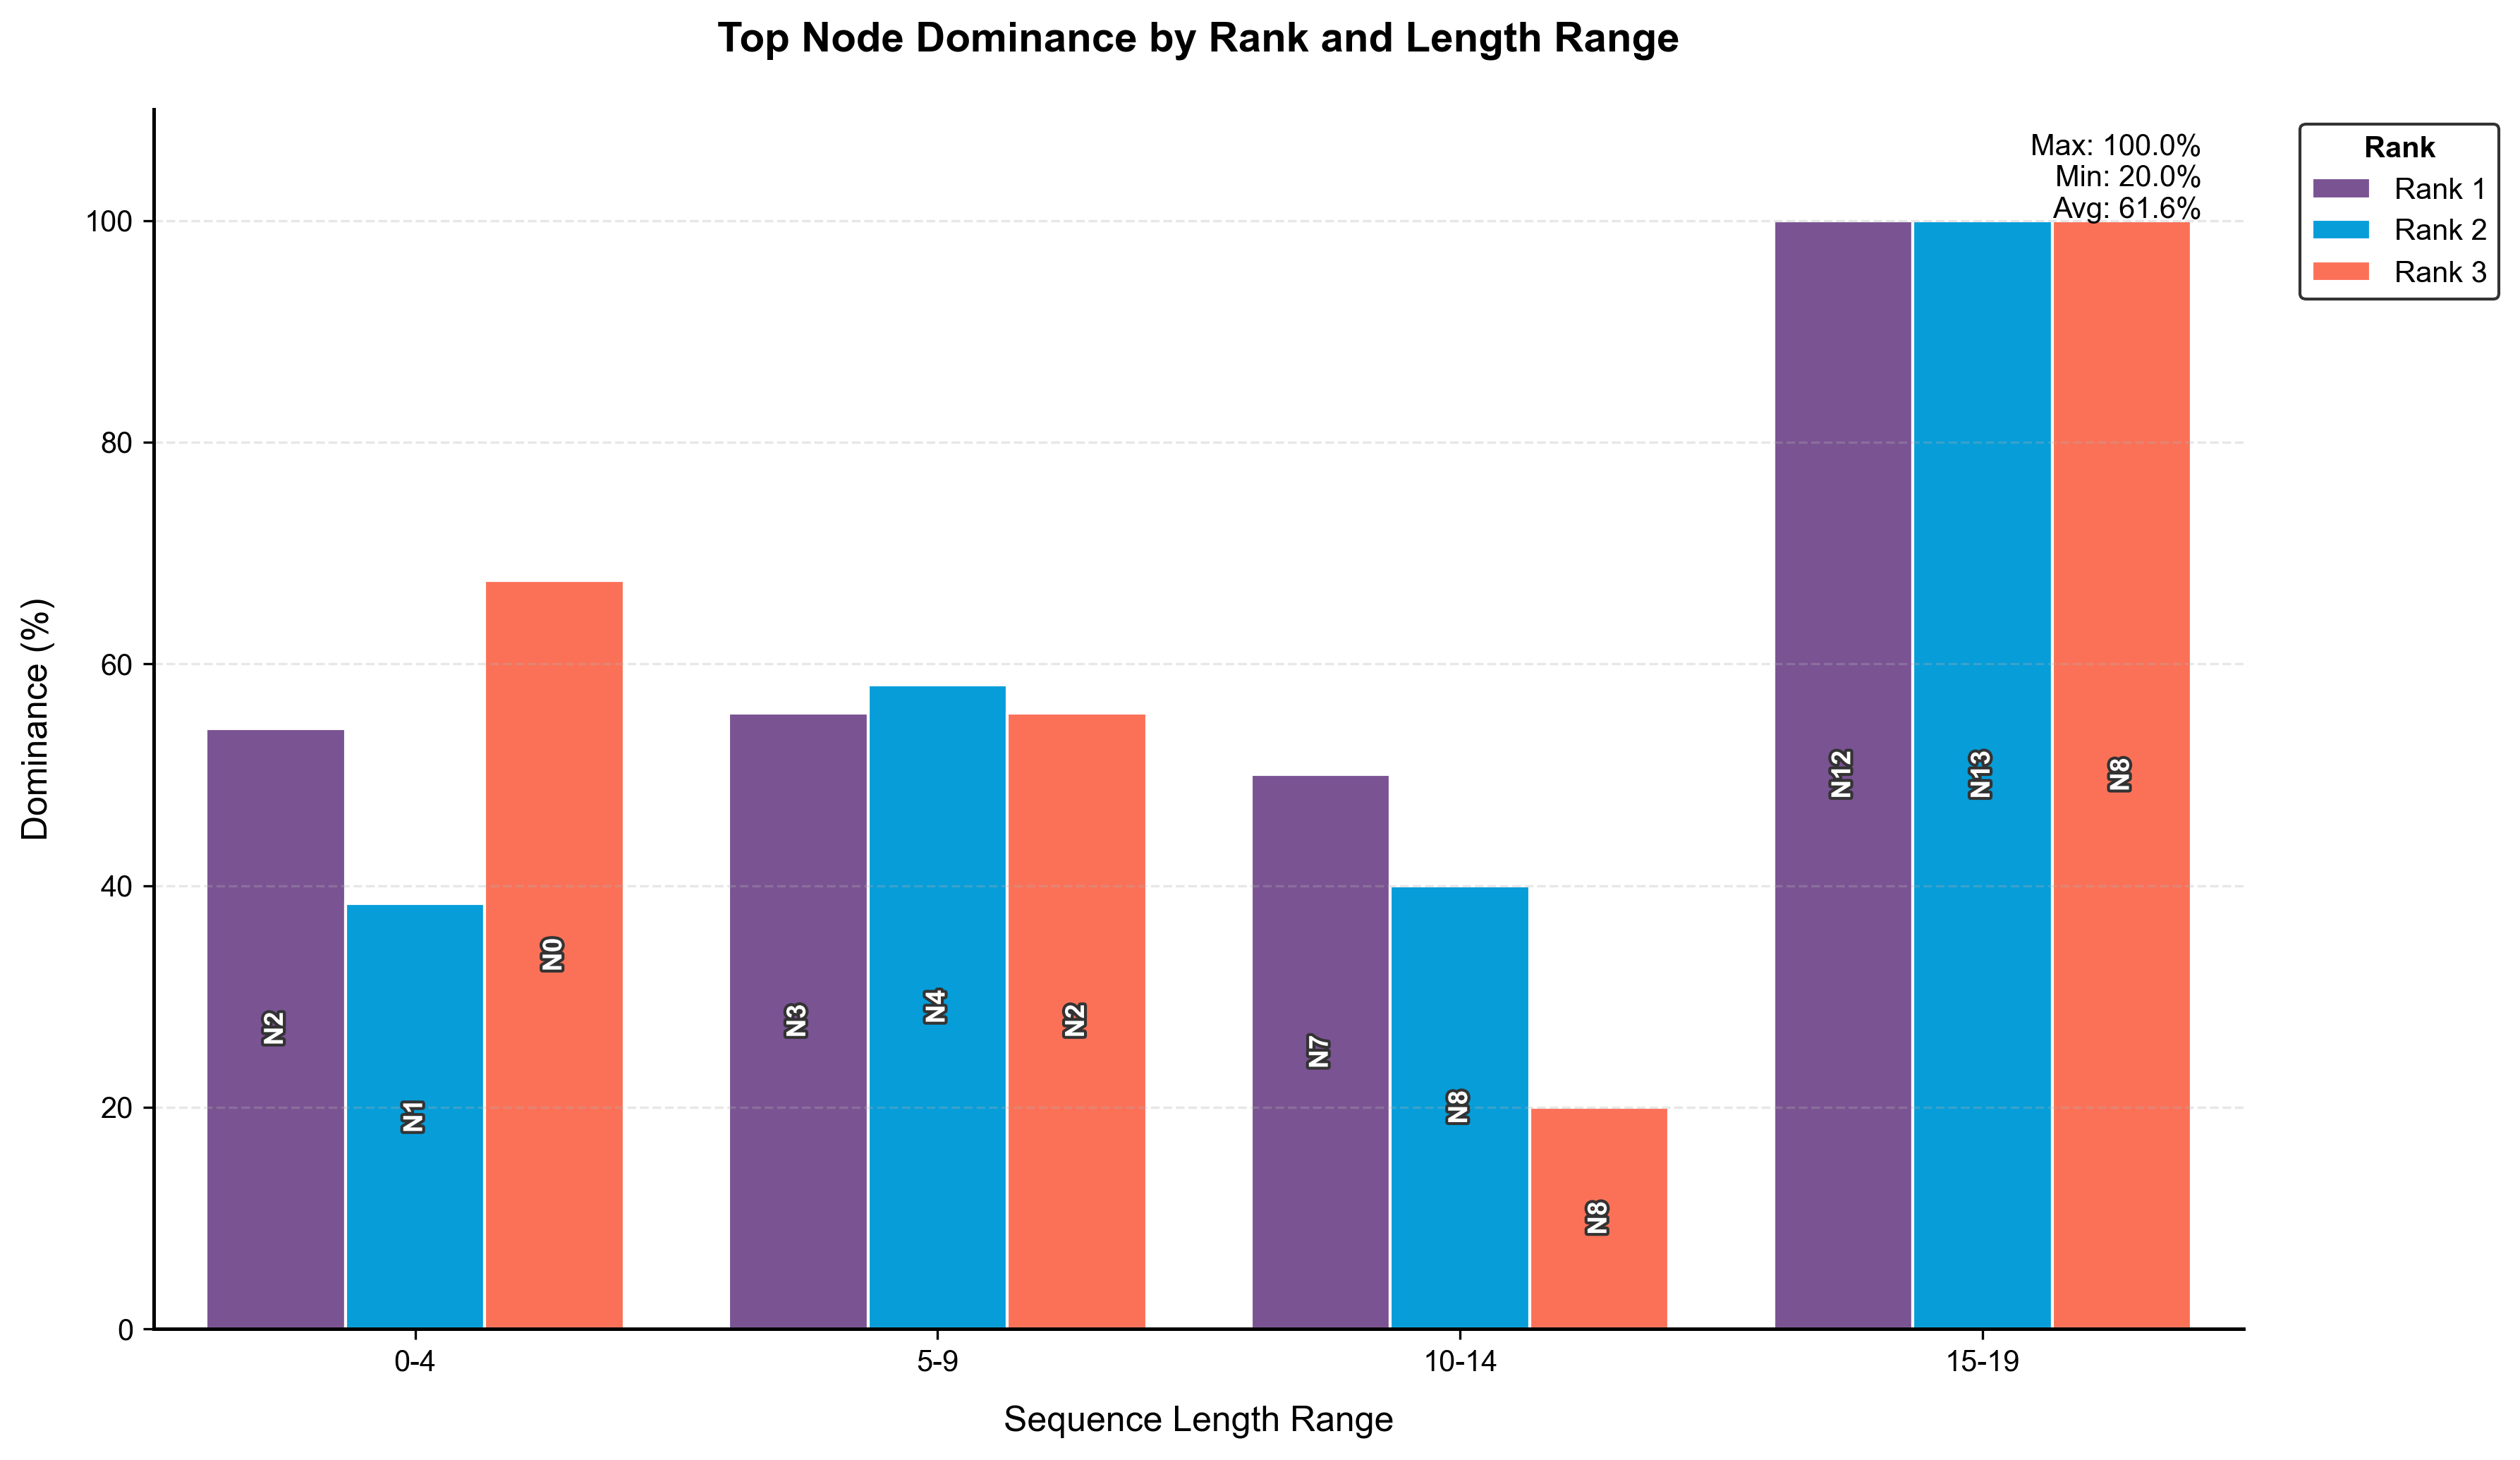

In [25]:
plot_rank_dominance(range_stats, 
                    title="Top Node Dominance by Rank and Length Range", 
                    save_path="../output/picts/BPI12w_timeedgedecay_noderankbar")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


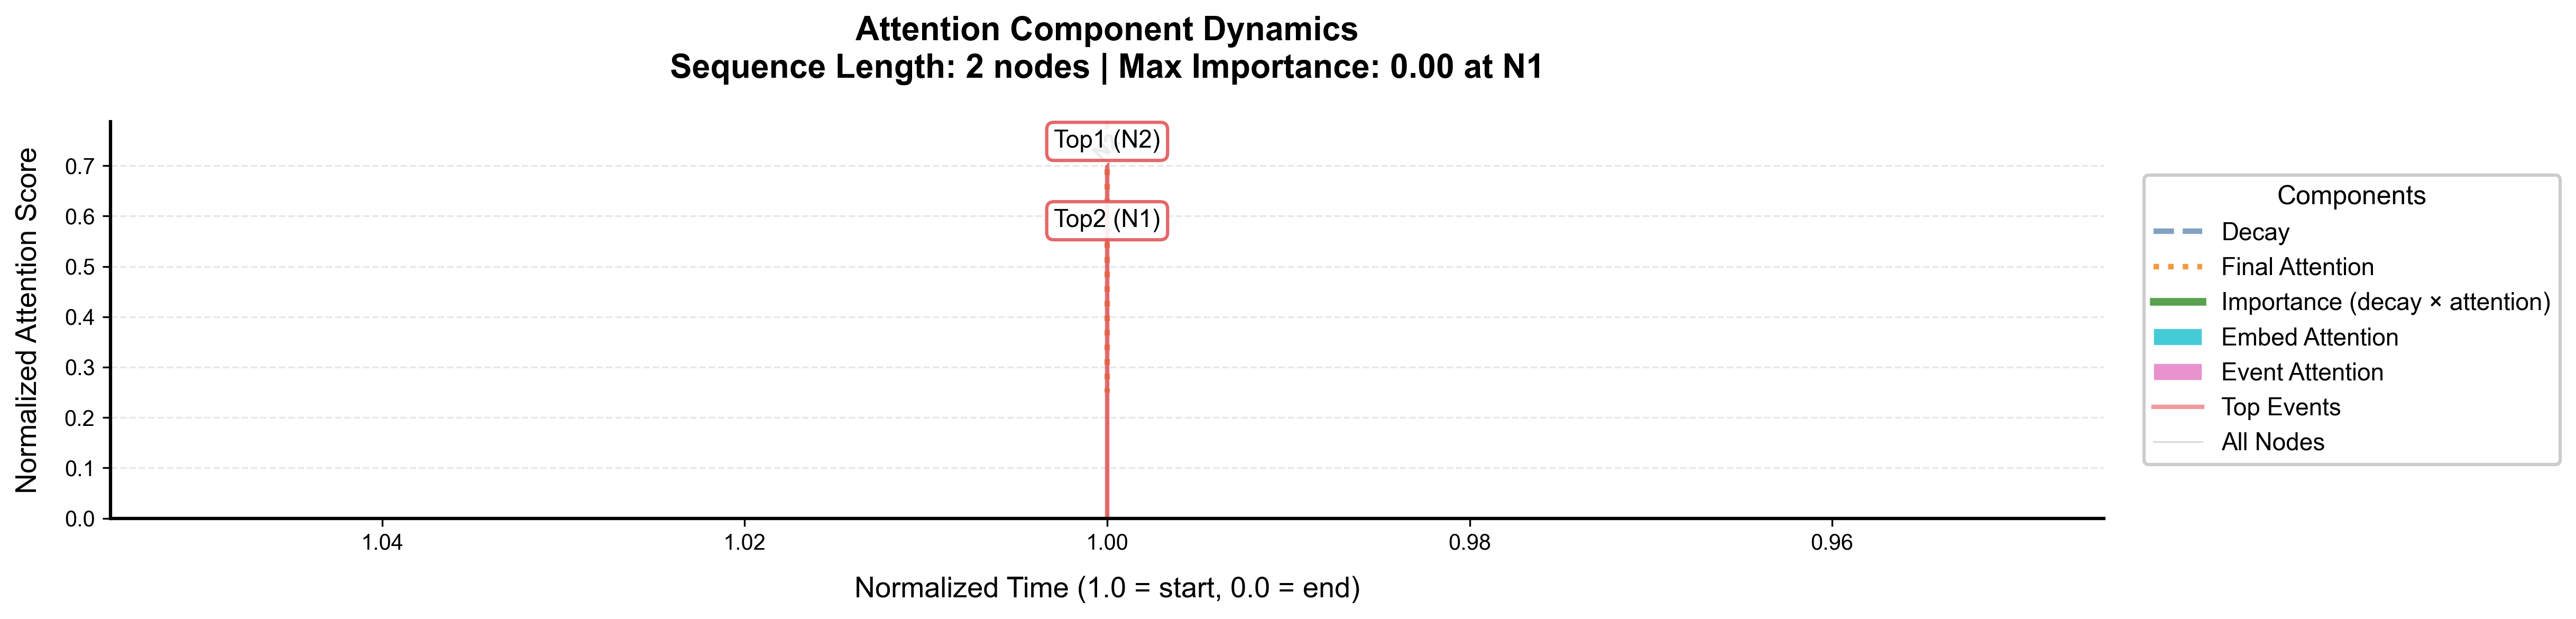

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [26]:
plot_importance_timeline(attention_data, min_length=2, max_length=10, figsize=(20, 4),
                        save_path="../output/picts/BPI12w_timedgedecay_sampletimeline")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


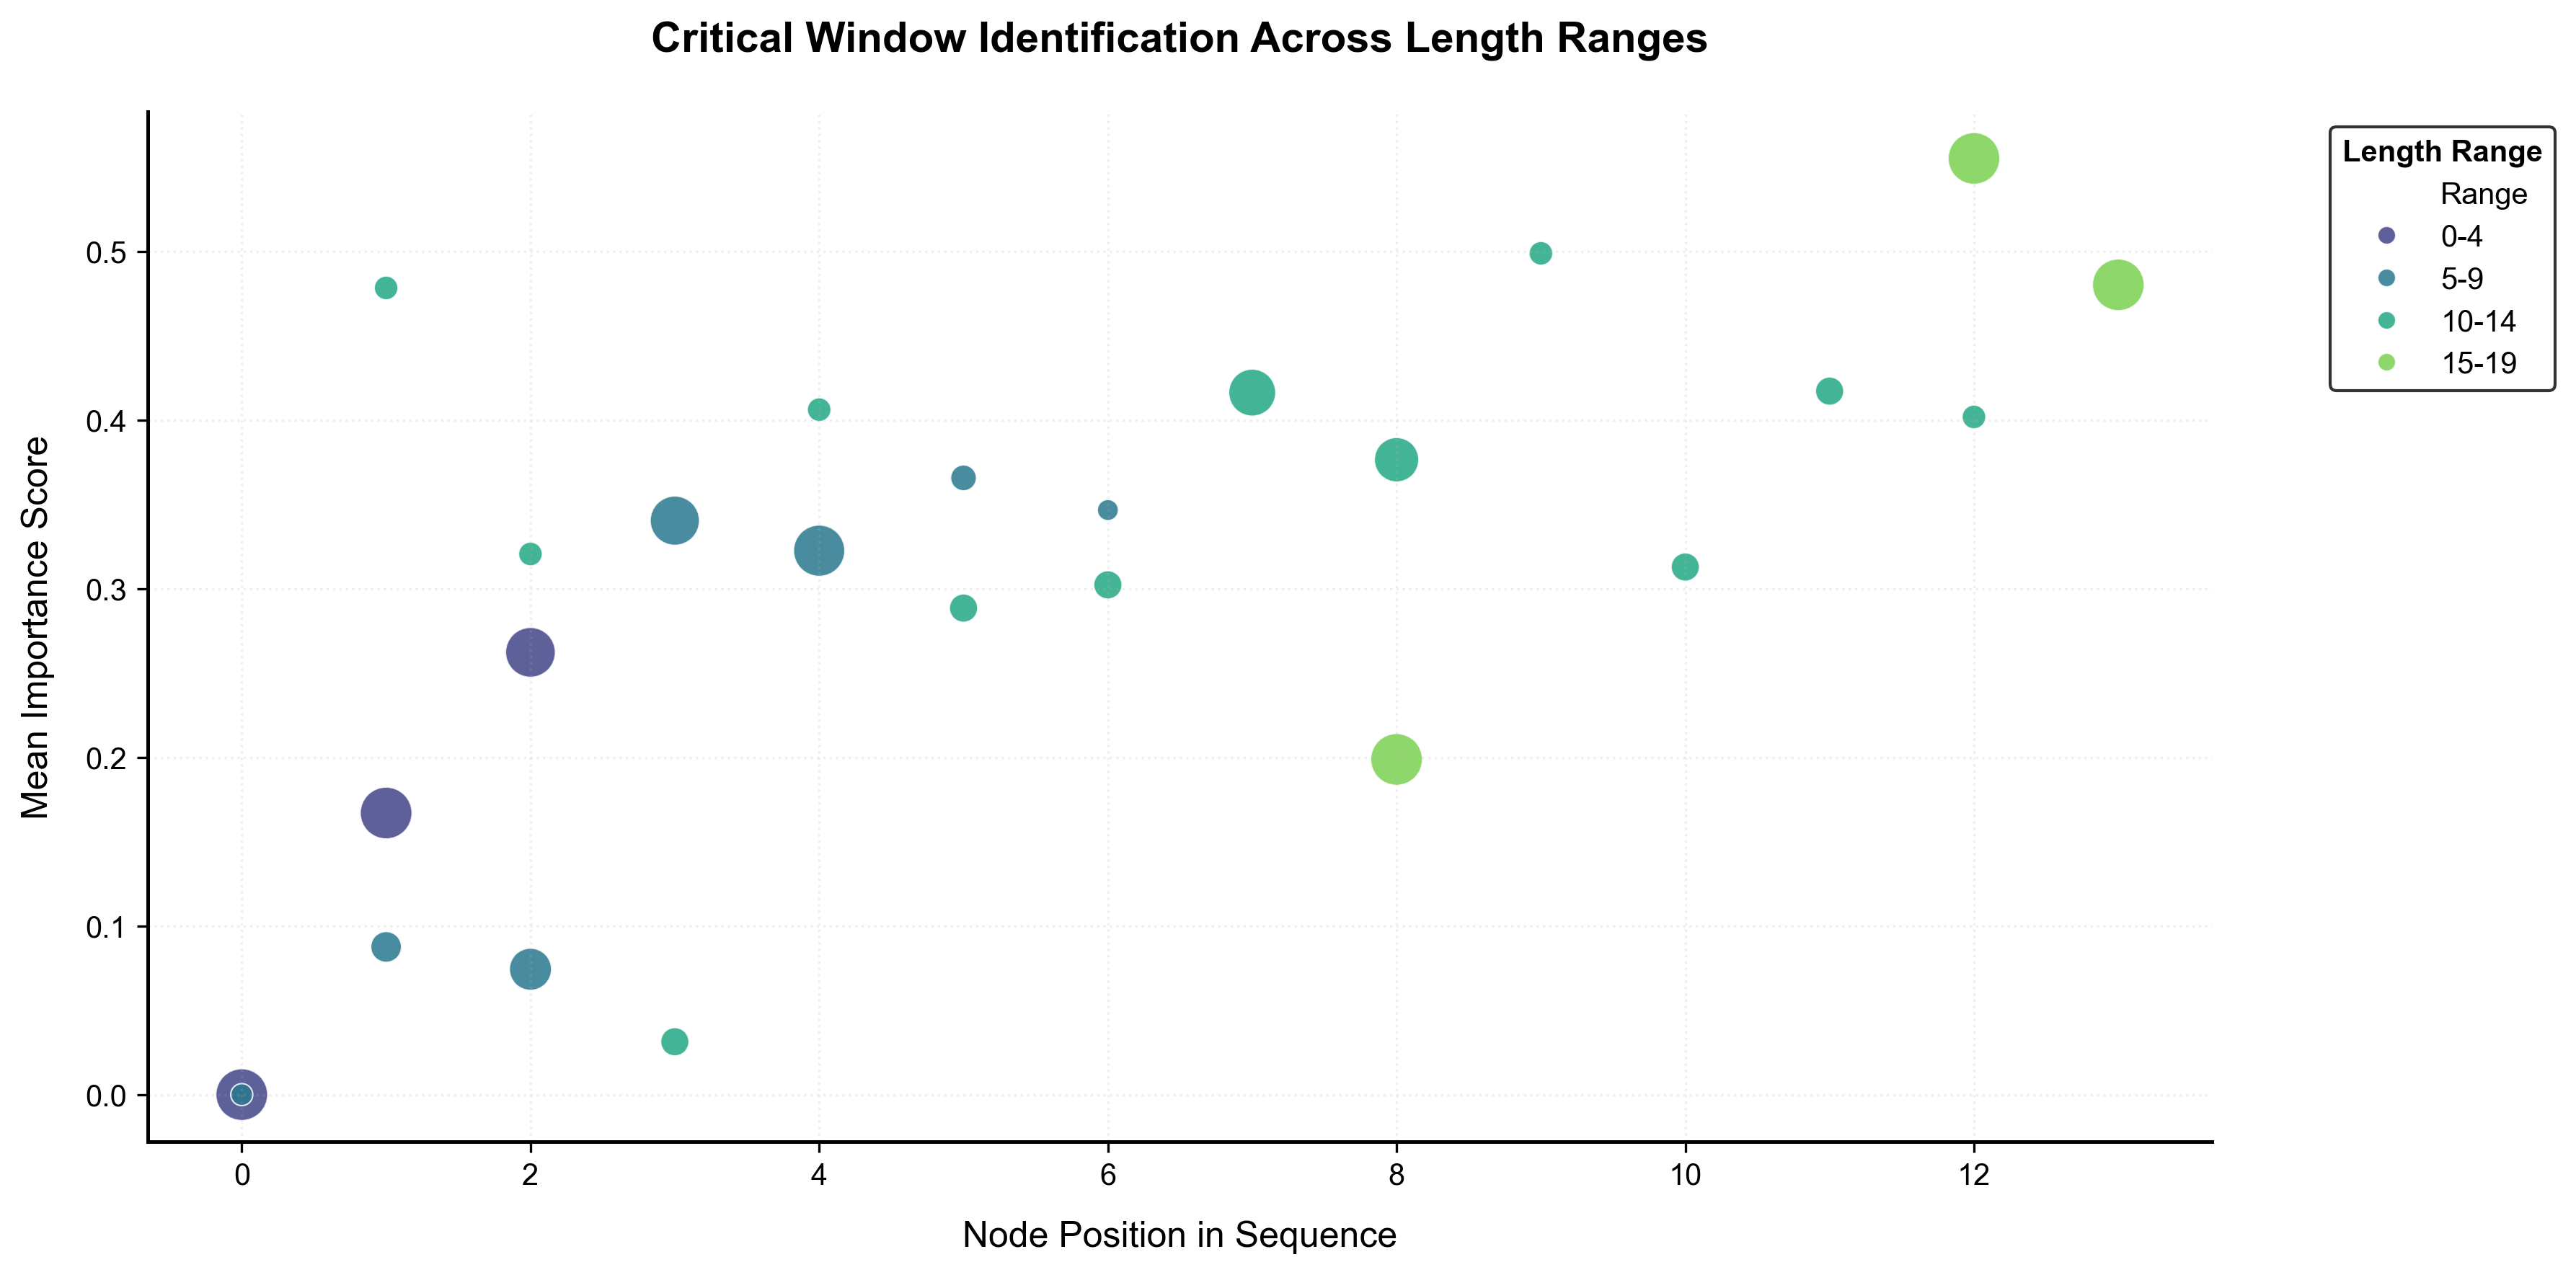

In [27]:
window_stats = plot_critical_windows(attention_data, length_bins, figsize=(12, 6), 
                                     compare_ranges=None, alpha=0.05, 
                                     save_path="../output/picts/BPI12w_timedgedecay_criticwin_nocomp")
window_stats.to_csv("../output/statis/BPI12w_timedgedecay_criticwindows.csv", index=False)

In [30]:
pairwise_table = generate_pairwise_ttest_table(window_stats, length_bins, alpha=0.05)
top_significant, top_comparison_tuples = get_top_significant_ranges(pairwise_table, num_top=10)

In [31]:
top_significant

,Comparison,Mean Diff,t-statistic,p-value,Cohen's d,Significance,n1,n2
1,0-4 vs 10-14,-0.211,-2.64,2.024e-02,-1.71,*,3,12


In [32]:
top_significant.to_csv("../output/statis/BPI12w_timedgedecay_rangediff.csv", index=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


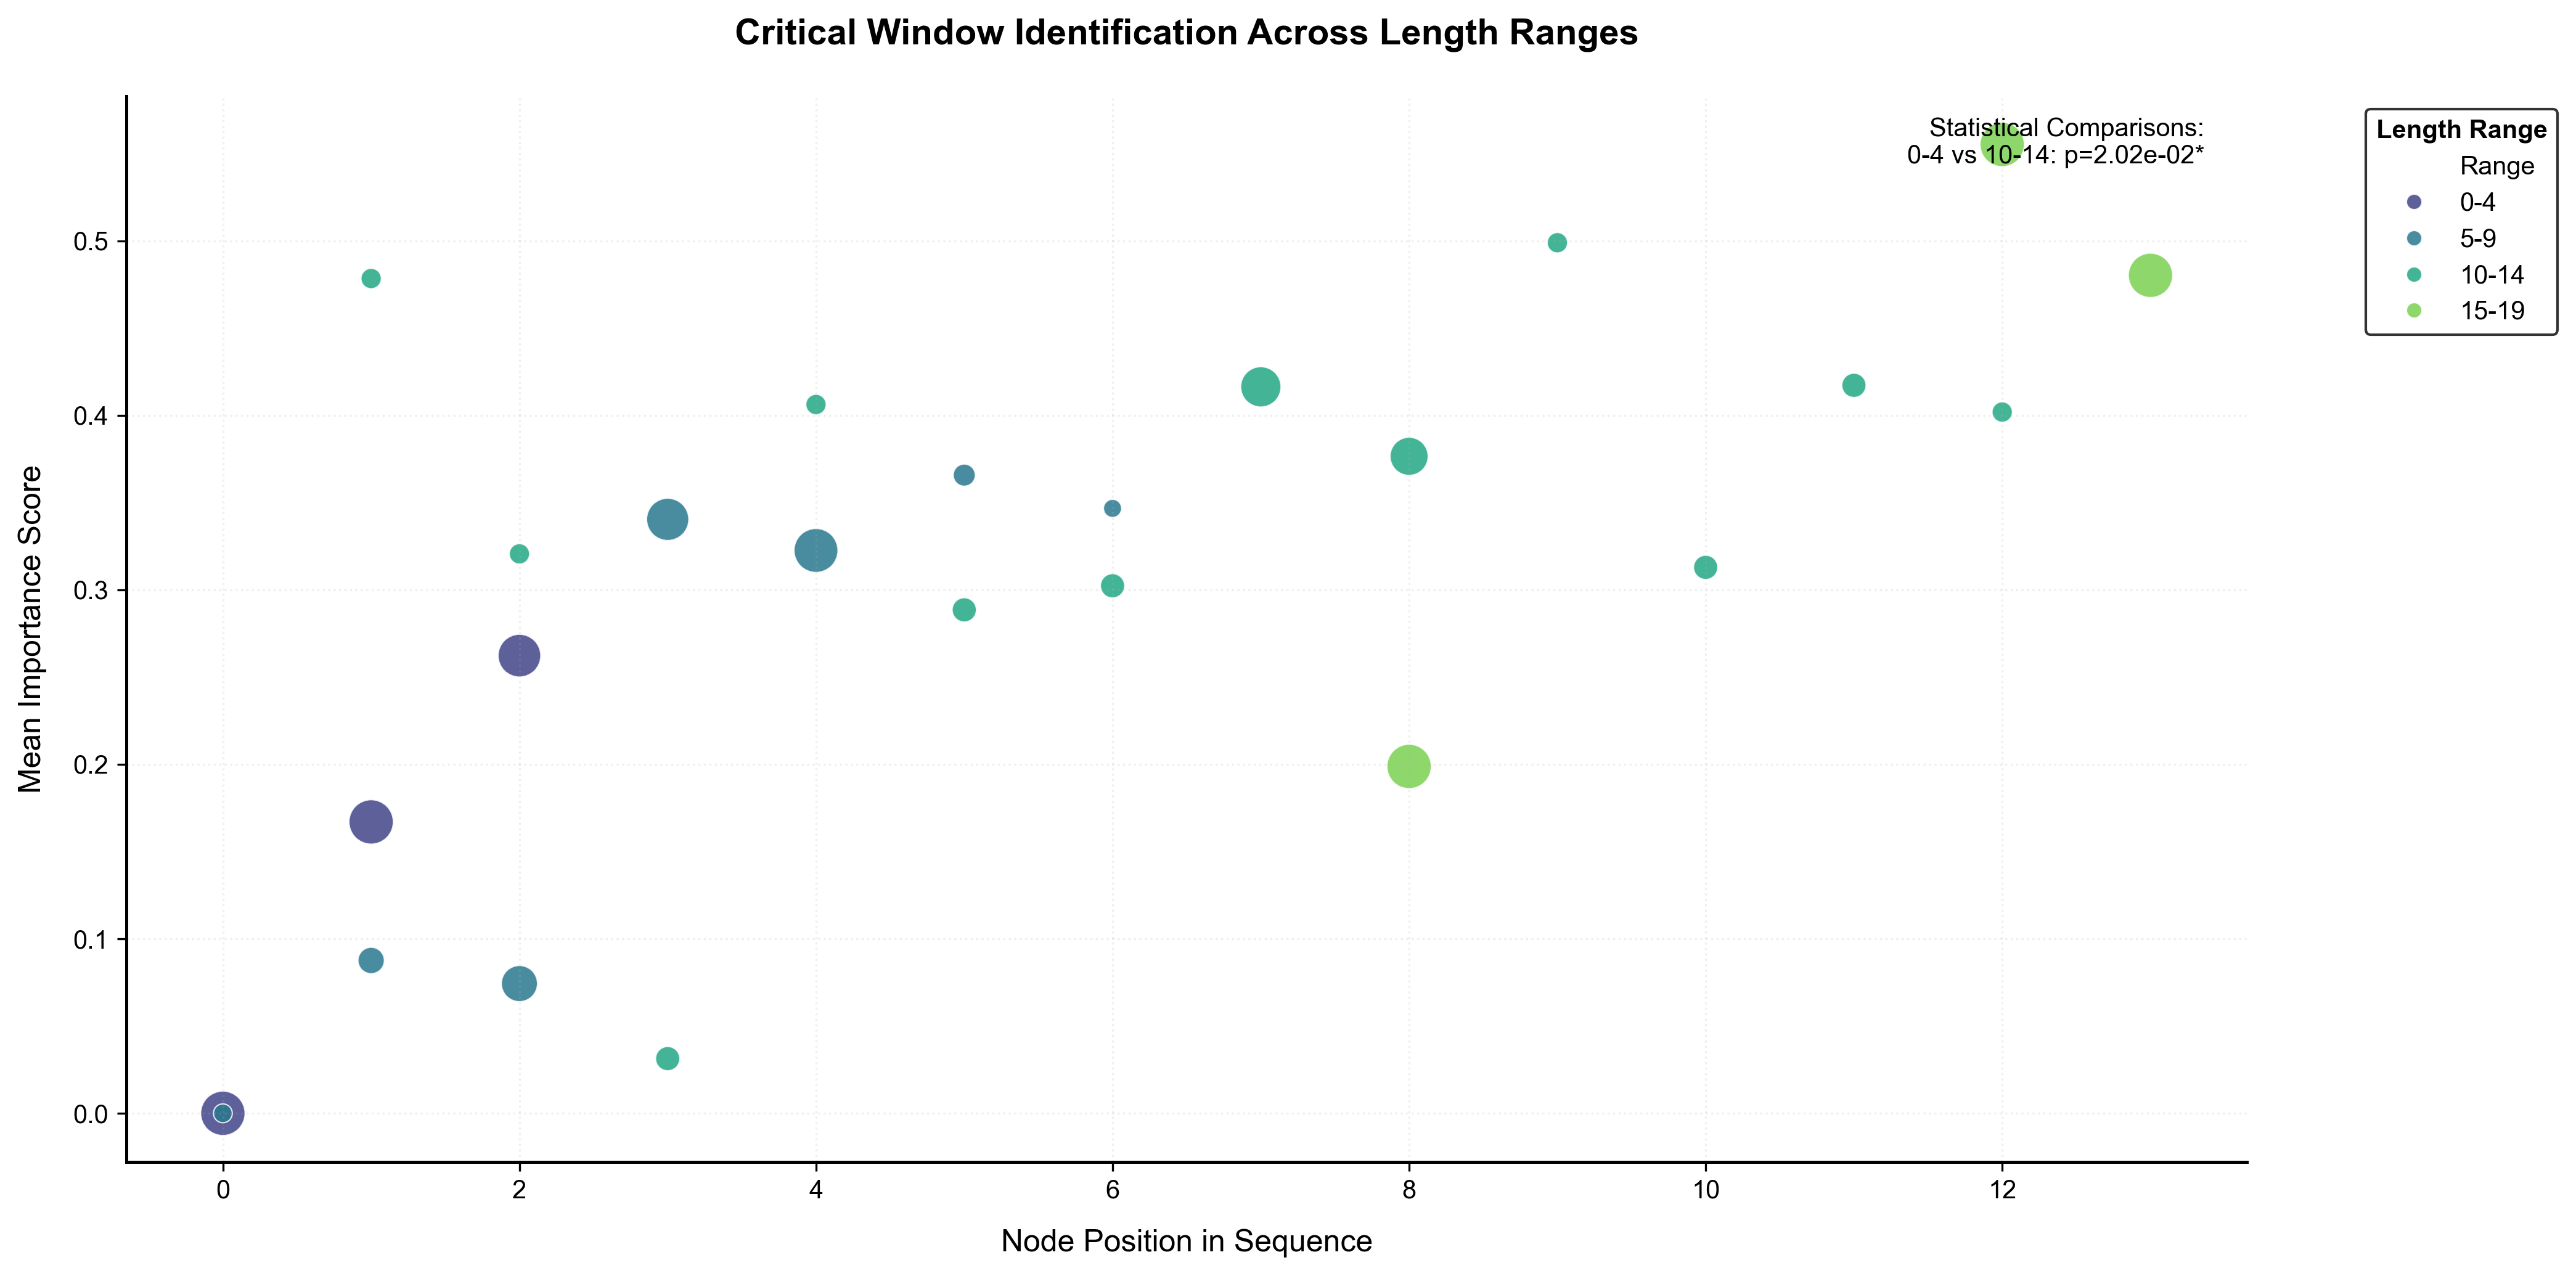

In [33]:
# Plot with significance markers
_ = plot_critical_windows(
        attention_data,
        length_bins,
        compare_ranges=top_comparison_tuples,
        figsize=(14,7),
        alpha=0.05, 
        save_path="../output/picts/BPI12w_timedgedecay_criticwin_comp")

In [34]:
# Step 1: Calculate metrics
df_metrics = calculate_window_metrics(attention_data, length_bins)

# Step 2: Generate statistics table
stats_table = aggregate_metrics(df_metrics)


stats_table.columns = ['_'.join(col).strip() for col in stats_table.columns.values]
stats_table.to_csv("../output/statis/BPI12w_timedgedecay_attentionstatis.csv", index='Length Range')

stats_table

,Peak Attention_Mean,Peak Attention_SD,Peak Attention_N,Attention Span_Mean,Attention Span_SD,Peak Position_Mean,Peak Position_SD
Length Range,,,,,,,
0-4,0.293,0.115,552,0.329,0.154,0.368,0.161
5-9,0.420,0.070,351,0.310,0.080,0.555,0.095
10-14,0.474,0.040,10,0.236,0.076,0.638,0.204
15-19,0.555,NaN,1,0.133,NaN,0.800,NaN


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


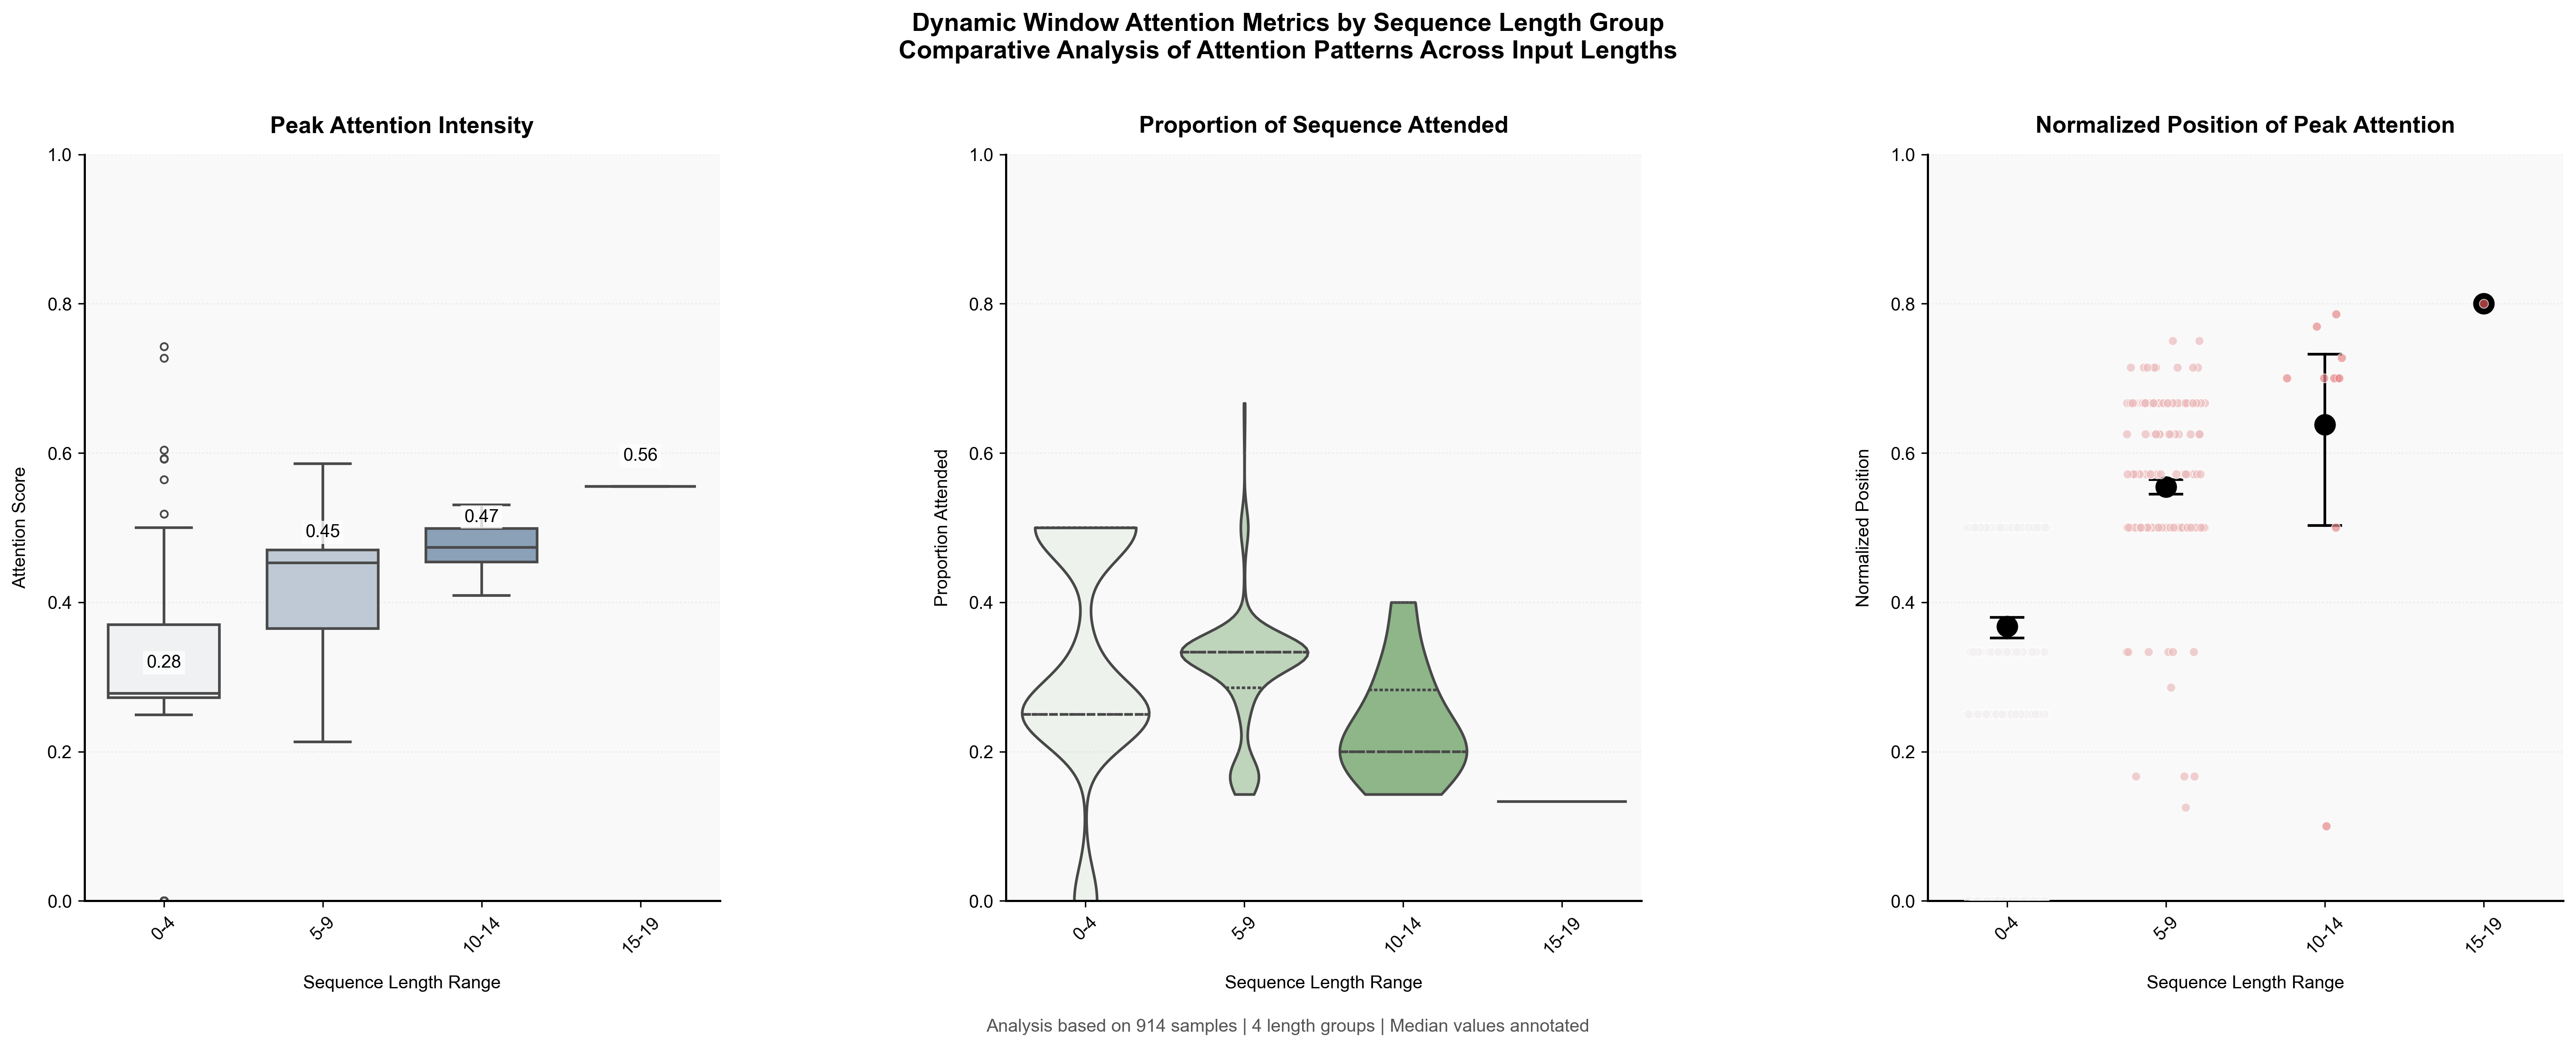

In [35]:
plot_window_metrics(df_metrics,
                   figsize=(20, 7), 
                   save_path="../output/picts/BPI12w_timedgedecay_attentionstatis")

In [36]:
preds, labels, outs = predict(model, test_loader, device)

# Check some predictions
for i in range(10):
    print(f"Predicted: {preds[i].item()} | Actual: {labels[i].item()}")

Predicted: 12 | Actual: 10
Predicted: 12 | Actual: 1
Predicted: 5 | Actual: 5
Predicted: 12 | Actual: 10
Predicted: 12 | Actual: 1
Predicted: 5 | Actual: 5
Predicted: 12 | Actual: 10
Predicted: 12 | Actual: 1
Predicted: 5 | Actual: 5
Predicted: 12 | Actual: 10


In [37]:
top1 = top_k_accuracy(outs, labels, k=1)
top3 = top_k_accuracy(outs, labels, k=3)
top5 = top_k_accuracy(outs, labels, k=5)

print(f"Top-1 Acc: {top1:.4f} | Top-3 Acc: {top3:.4f} | Top-5 Acc: {top5:.4f}")

Top-1 Acc: 0.7273 | Top-3 Acc: 0.9547 | Top-5 Acc: 0.9870


In [38]:
preds_seq, labels_seq = predict_per_sequence(model, test_loader, device)

In [39]:
bleu = average_bleu_score(preds_seq, labels_seq)
print(f"Average BLEU Score: {bleu:.4f}")

Average BLEU Score: 0.2904


In [40]:
avg_dls, exact_acc = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"Damerau-Levenshtein Similarity (avg): {avg_dls:.4f}")
print(f"Exact Match Accuracy: {exact_acc:.4f}")

Damerau-Levenshtein Similarity (avg): 0.7227
Exact Match Accuracy: 0.0033


In [41]:
# Usage
seq_top3_acc = sequence_level_top_k_accuracy(model, test_loader, device, k=3)
print(f"Sequence-Level Top-3 Accuracy: {seq_top3_acc:.4f}")
seq_top5_acc = sequence_level_top_k_accuracy(model, test_loader, device, k=5)
print(f"Sequence-Level Top-5 Accuracy: {seq_top5_acc:.4f}")

Sequence-Level Top-3 Accuracy: 0.8457
Sequence-Level Top-5 Accuracy: 0.9606


In [42]:
# Usage example
pos_errors, error_types, seq_stats = analyze_sequence_errors(model, test_loader, device, k=3)


=== Error Analysis Report ===
Total sequences analyzed: 914
Total sequences with errors: 911
Sequence length stats: {'min': 3, 'max': 15, 'mean': 4.878555798687089, 'median': 4.0}

Error distribution by position:
Position 0: 135 errors (11.1% of all errors)
Position 1: 858 errors (70.6% of all errors)
Position 2: 97 errors (8.0% of all errors)
Position 3: 53 errors (4.4% of all errors)
Position 4: 28 errors (2.3% of all errors)
Position 5: 20 errors (1.6% of all errors)
Position 6: 9 errors (0.7% of all errors)
Position 7: 5 errors (0.4% of all errors)
Position 8: 5 errors (0.4% of all errors)
Position 9: 3 errors (0.2% of all errors)
Position 10: 3 errors (0.2% of all errors)

Most common error types:
Predicted 12 instead of 10: 626 times
Predicted 12 instead of 14: 255 times
Predicted 12 instead of 0: 82 times
Predicted 12 instead of 1: 51 times
Predicted 10 instead of 14: 33 times
Predicted 12 instead of 8: 26 times
Predicted 10 instead of 12: 26 times
Predicted 10 instead of 1: 22

In [43]:
# First get predictions with probabilities
all_preds, all_labels, all_topk = predict_per_sequence_with_probs(model, test_loader, device, k=3)

# Then analyze sequence-level top-k accuracy
topk_acc, error_stats = sequence_level_top_k_analysis(all_topk, all_labels)

print(f"Sequence-Level Top-3 Accuracy: {topk_acc:.4f}")
print("\nError Analysis:")
print(f"- Most error-prone positions: {error_stats['position_errors']}")
print(f"- Top prediction mistakes: {error_stats['top_errors']}")

Sequence-Level Top-3 Accuracy: 0.8457

Error Analysis:
- Most error-prone positions: {0: 61, 1: 88, 2: 25, 3: 9, 4: 5, 5: 7, 6: 3, 7: 2, 8: 1, 9: 1}
- Top prediction mistakes: {(12, 0): 82, (12, 1): 45, (12, 8): 26, (12, 2): 12, (10, 5): 5}


In [44]:
show_error_sequences(all_topk, all_labels, num=3)


Error Sequence #1:
True: [10, 1, 5]
Pred: [12, 12, 5]
Mismatches:
Pos 1: True 1 not in [12, 10, 14]

Error Sequence #2:
True: [10, 1, 5]
Pred: [12, 12, 5]
Mismatches:
Pos 1: True 1 not in [12, 10, 14]

Error Sequence #3:
True: [10, 1, 5]
Pred: [12, 12, 5]
Mismatches:
Pos 1: True 1 not in [12, 10, 14]


In [45]:
from sklearn.metrics import classification_report
unique_true = np.unique(labels.cpu().numpy())
unique_preds = np.unique(preds.cpu().numpy())

print("Classes in true labels:", unique_true)
print("Classes in predictions:", unique_preds)
print("Missing classes:", set(unique_true) - set(unique_preds))

actual_classes = np.union1d(unique_true, unique_preds)
report = classification_report(
    labels.cpu().numpy(),
    preds.cpu().numpy(),
    target_names=[f"Class_{i}" for i in actual_classes] ,
    digits=4
)
print(report)

Classes in true labels: [ 0  1  2  5  8  9 10 11 12 14]
Classes in predictions: [ 1  5  9 10 12 14]
Missing classes: {0, 8, 2, 11}
              precision    recall  f1-score   support

     Class_0     0.0000    0.0000    0.0000        83
     Class_1     0.9674    0.9162    0.9411       907
     Class_2     0.0000    0.0000    0.0000        16
     Class_5     0.9978    0.9891    0.9934       914
     Class_8     0.0000    0.0000    0.0000        33
     Class_9     0.0000    0.0000    0.0000         4
    Class_10     0.7815    0.3467    0.4803      1001
    Class_11     0.0000    0.0000    0.0000         2
    Class_12     0.5093    0.9564    0.6646      1146
    Class_14     0.6701    0.1841    0.2889       353

    accuracy                         0.7273      4459
   macro avg     0.3926    0.3392    0.3368      4459
weighted avg     0.7607    0.7273    0.6966      4459



/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [46]:
# Load model state
checkpoint = torch.load(model_path, map_location=device)
config = checkpoint['config']

# Rebuild the model using the same config
model = DualGATTimeAwareModel(
    num_event_features=config['num_event_features'],
    num_embedding_features=config['num_embedding_features'],
    embedding_dims=config['embedding_dims'],
    gat_hidden_dim_event=config['gat_hidden_dim_event'],
    gat_hidden_dim_embed=config['gat_hidden_dim_embed'],
    gat_hidden_dim_concat=config['gat_hidden_dim_concat'],
    output_dim=config['output_dim'],
    num_heads=config['num_heads'],
    lambda_decay=config['lambda_decay']
)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

# Rebuild optimizer (if needed)
optimizer = torch.optim.Adam(model.parameters())
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Recover attention and event IDs
start_epoch = checkpoint['epoch'] + 1 
attention_data = checkpoint['attention_data']

for epoch in range(start_epoch, 20):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, attention_data = evaluate(model, test_loader, criterion, device, return_attention=True)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

    if early_stopping(test_loss):
        print("Early stopping triggered.")
        break

    if early_stopping.best_loss_updated:
        print(f"New best model at epoch {epoch+1}, saving to {model_path}")
        best_model_saved = True
         # Save state dict and config
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config,
            'attention_data': attention_data
        }, model_path)

Epoch 9/10 | Train Loss: 0.6968 Acc: 0.7486 | Test Loss: 0.8393 Acc: 0.7282
Early stopping triggered.
